## MODELLING

### 1. Logistic Regression- Baseline

A simple baseline model is used as the starting point for the AgriScore credit scoring system.
The purpose of a baseline model is not to achieve the highest accuracy, but to establish a reference performance level that future models can be compared against.

Logistic Regression is used as the primary baseline model because:

- It is simple, fast, and easy to interpret
- It provides probabilistic outputs (useful for credit risk scoring)
- It assumes a linear relationship between features and the target variable
- It works well as a first benchmark in classification problems

In the context of AgriScore, Logistic Regression helps us understand how individual factors such as yield, stability, and household characteristics contribute to the likelihood of a farmer being creditworthy.

### Importing Libraries

In this section, we import the necessary Python libraries for data analysis and preprocessing.



In [1]:
# Import libraries
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import seaborn as sns

import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="viridis")
import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In this step, we load the cleaned dataset into the notebook using pandas.



In [2]:
import pandas as pd

# '..' moves out of Notebooks, then we enter 'Data sets'
final_data= pd.read_csv("../Data sets/Final_dataset.csv")
final_data.head()

,Unnamed: 0,hh_size,hh_dependency_ratio,age_manager,hh_primary_education,hh_formal_education,farm_size,farm_work,livestock,inorganic_fertilizer,...,cashflow_volatility,balance_stability,fraud_rate,input_efficiency,climate_risk_score,hh_shock,drought_shock,dist_market,country,main_crop_clean
0,0,13.0,0.3,44.4,1.0,1.0,3.103942,1.0,0.0,0.0,...,3.107012,4.965882e+07,0.636364,0.0,0.237516,1.0,0.000000,60.700001,Tanzania,OTHER
1,1,4.0,1.0,81.0,1.0,1.0,3.658361,0.0,0.0,0.0,...,1.592171,2.705629e+07,0.733333,0.0,0.258148,1.0,0.166667,60.700001,Tanzania,OTHER
2,2,4.0,3.0,72.0,1.0,1.0,1.210011,1.0,0.0,0.0,...,1.814533,1.185635e+08,0.250000,0.0,0.176846,0.0,0.000000,60.700001,Tanzania,MAIZE
3,3,2.0,1.0,31.0,0.0,1.0,3.354847,1.0,0.0,0.0,...,0.000000,2.933951e+07,0.000000,0.0,0.319816,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT
4,4,3.0,0.5,38.0,0.0,1.0,6.689459,1.0,0.0,0.0,...,1.300629,2.887447e+07,0.600000,0.0,0.226742,0.0,0.000000,60.700001,Tanzania,TUBERS_ROOT


In [3]:
final_data.shape

(11408, 34)

In [4]:
final_data.columns

Index(['Unnamed: 0', 'hh_size', 'hh_dependency_ratio', 'age_manager',
       'hh_primary_education', 'hh_formal_education', 'farm_size', 'farm_work',
       'livestock', 'inorganic_fertilizer', 'fertilizer_per_ha', 'yield_kg_ha',
       'yield_stability', 'yield_per_ha', 'rainfall_mm', 'soil_quality_index',
       'soil_npk', 'drought_risk', 'climate_stress_index', 'crop_health_index',
       'tx_frequency', 'total_volume', 'avg_transaction',
       'input_purchase_ratio', 'cashflow_volatility', 'balance_stability',
       'fraud_rate', 'input_efficiency', 'climate_risk_score', 'hh_shock',
       'drought_shock', 'dist_market', 'country', 'main_crop_clean'],
      dtype='str')

In [5]:
final_data.isnull().sum()

Unnamed: 0              0
hh_size                 0
hh_dependency_ratio     0
age_manager             0
hh_primary_education    0
hh_formal_education     0
farm_size               0
farm_work               0
livestock               0
inorganic_fertilizer    0
fertilizer_per_ha       0
yield_kg_ha             0
yield_stability         0
yield_per_ha            0
rainfall_mm             0
soil_quality_index      0
soil_npk                0
drought_risk            0
climate_stress_index    0
crop_health_index       0
tx_frequency            0
total_volume            0
avg_transaction         0
input_purchase_ratio    0
cashflow_volatility     0
balance_stability       0
fraud_rate              0
input_efficiency        0
climate_risk_score      0
hh_shock                0
drought_shock           0
dist_market             0
country                 0
main_crop_clean         0
dtype: int64

In [6]:
# import seaborn as sns

# sns.boxplot(x=final_data['good_borrower'], y=final_data['yield_per_ha'])

### Creating the Target Variable: Good Borrower

In this step, we define the target variable `good_borrower`, which represents whether a farmer is creditworthy or not.

A farmer is labeled as a **good borrower (1)** if they meet the following conditions:

- Their yield per hectare is above the median value  
- Their balance stability is above the median value  
- Their climate risk score is below the median value  

Otherwise, they are labeled as a **bad borrower (0)**.

This rule-based approach helps us create a clear classification target for the machine learning model.

In [7]:
# final_data['good_borrower'] = np.where(
#     (
#         (final_data['yield_per_ha'] > final_data['yield_per_ha'].median()) &
#         (final_data['balance_stability'] > final_data['balance_stability'].median()) &
#         (final_data['climate_risk_score'] < final_data['climate_risk_score'].median())
#     ),
#     1,
#     0
# )

In [8]:

np.random.seed(42)

score = (
    (final_data['yield_per_ha'] > final_data['yield_per_ha'].median()).astype(int) +
    (final_data['balance_stability'] > final_data['balance_stability'].median()).astype(int) +
    (final_data['climate_risk_score'] < final_data['climate_risk_score'].median()).astype(int)
)

# introduce randomness (real-world uncertainty)
final_data['good_borrower'] = np.where(
    (score + np.random.normal(0, 0.5, len(final_data))) > 2,
    1,
    0
)

#### Encoding Categorical Variables

In this step, we convert categorical variables into numerical format using **One-Hot Encoding**.


In [9]:
final_data = pd.get_dummies(
    final_data,
    columns=['country', 'main_crop_clean'],
    drop_first=True
)

#### Defining Features (X) and Target (y)

Here, we separate the dataset into:

- **X (features):** All independent variables used for prediction  
- **y (target):** The `good_borrower` column, which we aim to predict  

This step prepares the data for model training.

In [10]:
X = final_data.drop('good_borrower', axis=1)

y = final_data['good_borrower']

In [11]:
leakage_cols = ['yield_per_ha', 'balance_stability', 'climate_risk_score']

X = final_data.drop(columns=['good_borrower'] + leakage_cols)

In [12]:
# import matplotlib.pyplot as plt
# plt.scatter(final_data['yield_per_ha'], final_data['balance_stability'],
#             c=final_data['good_borrower'])

#### Splitting the Dataset 

The dataset is split into training and testing sets using an 80/20 ratio. 

In [13]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

<Axes: xlabel='good_borrower'>

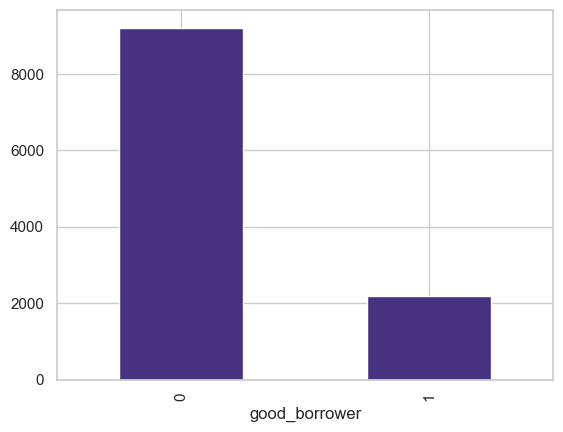

In [14]:
final_data['good_borrower'].value_counts().plot(kind='bar')

#### Handling Class Imbalance Using SMOTE

To address the imbalance in the dataset, SMOTE (Synthetic Minority Over-sampling Technique) is applied to the training data. SMOTE generates synthetic examples of the minority class (good borrowers) to create a balanced dataset. This helps the model learn patterns from both classes more effectively and improves its ability to correctly identify good borrowers.

In [15]:

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#### Check new class balance

<Axes: xlabel='good_borrower'>

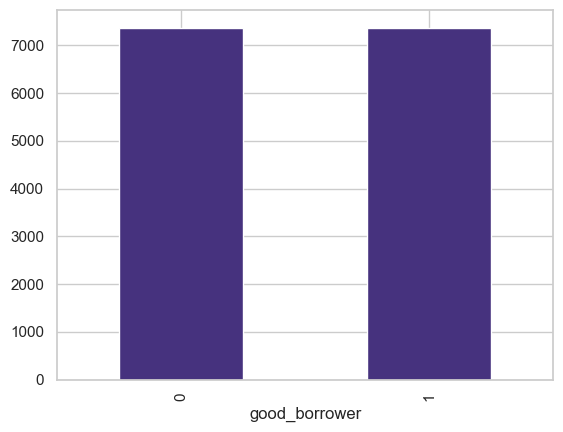

In [16]:
y_train_resampled.value_counts().plot(kind='bar')

#### Training the Logistic Regression Model

In this step, we train a Logistic Regression model on the training data.


In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_resampled, y_train_resampled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Making Predictions

After training the model, we use it to predict borrower status on the test dataset.

The output `y_pred` represents the model's predicted classification:
- 1 → Good borrower  
- 0 → Bad borrower  

These predictions will be compared with actual values for evaluation.

In [18]:
y_pred = model.predict(X_test)

#### Model Evaluation

We evaluate the model using standard classification metrics:

- **Accuracy Score** → Overall performance of the model  
- **Classification Report** → Includes precision, recall, and F1-score  

These metrics help us understand how well the model is performing in identifying good and bad borrowers.

Accuracy: 0.6879929886064855
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      1843
           1       0.34      0.68      0.46       439

    accuracy                           0.69      2282
   macro avg       0.62      0.69      0.62      2282
weighted avg       0.79      0.69      0.72      2282



<Axes: >

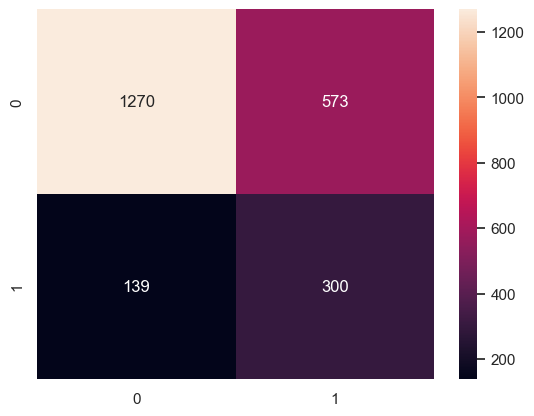

In [19]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')


#### Model Performance Interpretation(Logistic Regression)

The model shows a moderate overall performance with an accuracy of about **69%**. However, this performance is influenced by class imbalance in the dataset, where Class 0 has significantly more samples (1,843) compared to Class 1 (439).

The model performs well in identifying Class 0 (majority class), achieving high precision of around **90%**, meaning it is generally reliable when predicting this class. However, it still misses a portion of actual Class 0 cases, indicating some misclassification.

For Class 1 (minority class), the model performs moderately, with a recall of about **68%**, meaning it correctly identifies most of the positive cases. However, the precision for Class 1 is low (around **34%**), showing that many predictions of Class 1 are incorrect.

Overall, the model tends to generate a high number of false positives, frequently misclassifying Class 0 as Class 1 (573 cases). This indicates a trade-off where the model is more sensitive to detecting Class 1 but at the cost of reduced reliability when making those predictions.

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
19,tx_frequency,0.026106
23,cashflow_volatility,0.021297
1,hh_size,0.019763
3,age_manager,0.009677
22,input_purchase_ratio,0.008956
29,main_crop_clean_MAIZE,0.007994
32,main_crop_clean_OTHER,0.007642
35,main_crop_clean_TUBERS_ROOT,0.003603
15,soil_npk,0.003221
24,fraud_rate,0.002758


##  2. Decision Tree Model - Baseline

In this step, a Decision Tree Classifier is trained using the resampled training data to handle class imbalance. The model learns decision rules from the features to classify farmers as either good or bad borrowers. After training, predictions are made on the test set and the model is evaluated using accuracy and a classification report to assess its performance across both classes.

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7510955302366346
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1843
           1       0.38      0.44      0.41       439

    accuracy                           0.75      2282
   macro avg       0.62      0.63      0.62      2282
weighted avg       0.77      0.75      0.76      2282



#### Decision Tree Model Performance

The Decision Tree model achieved an accuracy of **75.1%**, showing a moderate ability to classify the data. It performs well on Class 0 (majority class), with high precision (0.86) and good recall (0.82), meaning it correctly identifies most Class 0 cases.

For Class 1 (minority class), the model shows weaker performance, with precision of 0.38 and recall of 0.44. This indicates that while it can detect some Class 1 cases, it still misses many and also produces a fair number of incorrect predictions.

Overall, the model is better at predicting Class 0 than Class 1, showing a bias toward the majority class. While performance is reasonable, there is still room for improvement in identifying the minority class more effectively.

## 3. Random Forest Model- Advanced

In this step, a Random Forest Classifier is trained using the resampled training data. The model builds multiple decision trees and combines their outputs to make more accurate and stable predictions. After training, predictions are made on the test set and evaluated using accuracy and a classification report to measure performance across both classes.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8172655565293602
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1843
           1       0.53      0.40      0.46       439

    accuracy                           0.82      2282
   macro avg       0.70      0.66      0.67      2282
weighted avg       0.80      0.82      0.81      2282



#### Random Forest Model Performance

The Random Forest model achieved an accuracy of **81.7%**, showing improved performance compared to simpler models. It performs well on Class 0 (majority class), with high precision (0.86) and recall (0.92), meaning it correctly identifies most bad borrowers.

For Class 1 (minority class), the model shows moderate performance, with precision of 0.53 and recall of 0.40. This indicates that while it can identify some good borrowers, it still misses a significant portion of them.

Overall, the model provides a better balance between both classes compared to previous models, but there is still room for improvement in correctly identifying the minority class.

## 4. XGBoost Model 

In this step, an XGBoost Classifier is trained using the resampled training data to improve predictive performance. XGBoost is a powerful boosting algorithm that builds trees sequentially to correct previous errors and capture complex patterns in the data.

After training, the model is used to make predictions on the test set, and performance is evaluated using accuracy and a classification report to assess how well it performs across both classes.

In [23]:
# pip install xgboost


In [24]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8238387379491674
              precision    recall  f1-score   support

           0       0.87      0.92      0.89      1843
           1       0.56      0.41      0.47       439

    accuracy                           0.82      2282
   macro avg       0.71      0.66      0.68      2282
weighted avg       0.81      0.82      0.81      2282



#### XGBoost Model Performance

The XGBoost model achieved an accuracy of **82.4%**, showing strong overall performance. It performs very well on Class 0 (majority class), with high precision (0.87) and recall (0.92), meaning it correctly identifies most bad borrowers.

For Class 1 (minority class), the model shows moderate performance, with precision of 0.56 and recall of 0.41. This indicates that it correctly identifies some good borrowers but still misses a considerable portion.

Overall, XGBoost provides a balanced improvement over previous models, especially in terms of stability and precision for the minority class, but there is still room for improving recall for better credit identification.

In [ ]:
# pip install lightgbm


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 846.3 kB/s eta 0:00:02
   -------------- ------------------------- 0.5/1.5 MB 846.3 kB/s eta 0:00:02
   -------------- ------------------------- 0.5/1.5 MB 846.3 kB/s eta 0:00:02
   ---------------------------- ----------- 1.0/1.5 MB 721.7 kB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 721.7 kB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 748.0 kB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 748.0 kB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 748.0 kB/s eta 0:00:01
   ----------------------------

In [28]:
X_train_resampled.columns = X_train_resampled.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_test.columns = X_test.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

In [29]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

lgbm_model.fit(X_train_resampled, y_train_resampled)

y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print(classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 7372, number of negative: 7372
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009292 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6136
[LightGBM] [Info] Number of data points in the train set: 14744, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Accuracy: 0.829535495179667
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1843
           1       0.58      0.42      0.49       439

    accuracy                           0.83      2282
   macro avg       0.72      0.67      0.69      2282
weighted avg       0.81      0.83      0.82      2282

